# 15 — Tropical Nights: person-days analysis

A **tropical night** is defined as a night when minimum temperature (Tmin) does not fall below a fixed threshold, preventing physiological recovery from daytime heat.  Two thresholds are standard in the literature:

| Threshold | Definition | Basis |
|---|---|---|
| **Tmin > 20 °C** | ETCCDI *tropical night* (TR20) | WMO standard; widely used globally |
| **Tmin > 25 °C** | *Warm tropical night* | Used in South/Southeast Asia and Brazil heat health studies |

Unlike TX90p (a relative threshold), tropical nights are absolute — they express the idea that the body needs Tmin below a physiological threshold to recover.  This makes them conceptually simple and clinically grounded.

This notebook replicates the person-days analysis structure from notebooks 07 and 07b, but uses Tmin with the two absolute tropical-night thresholds instead of TX90p / TN90p.  We ask the same question: **do person-night rankings reflect heat exposure or population distribution?**

**Prerequisites:** `01b_data_acquisition_tmin` (tmin NetCDF files), population grids and neighbourhood boundaries from notebook 07.

## Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
from scipy.stats import spearmanr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city_tmin, load_neighbourhood_boundaries,
    compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

DATA_DIR   = 'data'
DIAG_YEAR  = 2020
THRESHOLDS = {'TR20': 20.0, 'TR25': 25.0}   # tropical-night thresholds
CITY_KEYS  = ['salvador', 'teresina', 'caceres']

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:center; font-size:0.85em;'},
]

# ---- Load Tmin, population, neighbourhood boundaries -----------------------
tmins = {}
for c in CITY_KEYS:
    da = load_city_tmin(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    tmins[c] = da

gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

salvador: shape {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6496, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6496, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


## Multi-year climatology: how many tropical nights on average?

Before the neighbourhood analysis we establish the city-wide baseline: how many tropical nights occur per year on average (2003–2020), and how this varies by threshold.

City,Threshold,Tmin mean (°C),Mean nights/yr,Std (yr-to-yr),Min yr,Max yr,% nights/yr
"Salvador, Brazil",TR20 (>20 °C),21.6,102.5,12.2,81,122,28.1%
"Salvador, Brazil",TR25 (>25 °C),21.6,4.9,4.1,0,18,1.3%
"Teresina, Brazil",TR20 (>20 °C),23.3,356.0,3.5,345,360,97.5%
"Teresina, Brazil",TR25 (>25 °C),23.3,16.3,9.8,2,38,4.5%
"Cáceres, Brazil",TR20 (>20 °C),20.7,242.3,18.4,206,279,66.4%
"Cáceres, Brazil",TR25 (>25 °C),20.7,5.8,6.9,0,25,1.6%


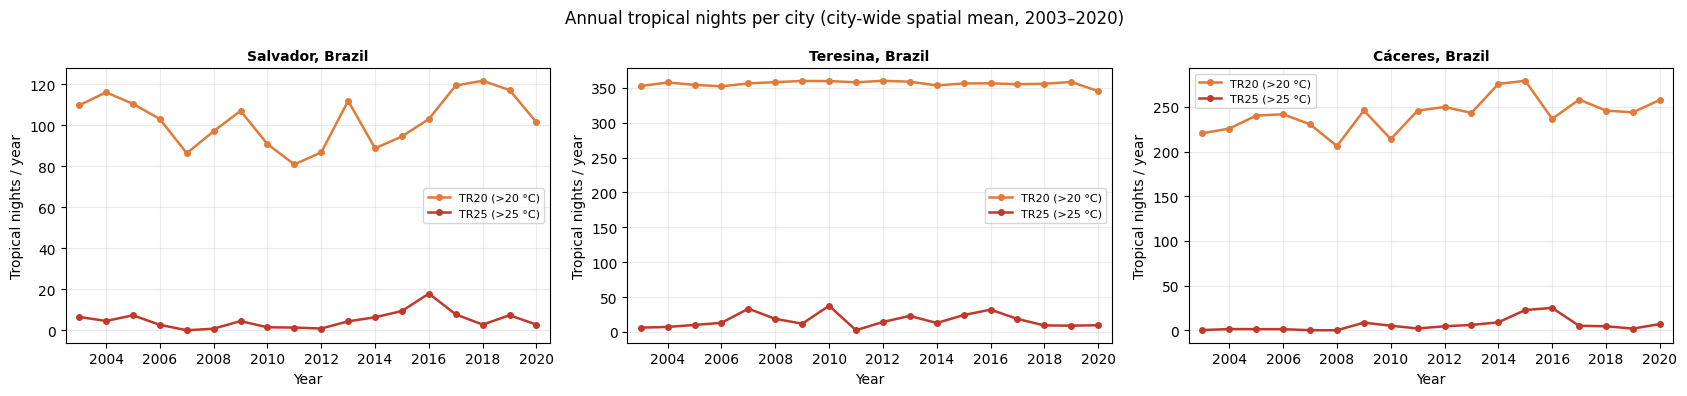

In [2]:
def annual_tropical_nights(da, threshold):
    """Annual count of tropical nights (Tmin > threshold) per pixel."""
    return (da > threshold).resample(time='YS').sum(dim='time')

# Pre-compute annual counts for both thresholds
annual = {c: {} for c in CITY_KEYS}
for c in CITY_KEYS:
    for name, thr in THRESHOLDS.items():
        annual[c][name] = annual_tropical_nights(tmins[c], thr)

# ---- City-wide multi-year mean (spatially averaged) -------------------------
clim_rows = []
for c in CITY_KEYS:
    tmin_vals = tmins[c]
    for name, thr in THRESHOLDS.items():
        ann = annual[c][name]
        city_mean = float(ann.mean(dim=['lat', 'lon']).mean('time'))
        city_std  = float(ann.mean(dim=['lat', 'lon']).std('time'))
        city_min  = float(ann.mean(dim=['lat', 'lon']).min('time'))
        city_max  = float(ann.mean(dim=['lat', 'lon']).max('time'))
        tmin_mean = float(tmin_vals.mean())
        clim_rows.append({
            'City':            CITIES[c]['label'],
            'Threshold':       f'TR{int(thr)} (>{thr:.0f} °C)',
            'Tmin mean (°C)':  tmin_mean,
            'Mean nights/yr':  city_mean,
            'Std (yr-to-yr)':  city_std,
            'Min yr':          city_min,
            'Max yr':          city_max,
            '% nights/yr':     100 * city_mean / 365,
        })

clim_df = pd.DataFrame(clim_rows)
display(
    clim_df.style
    .format({
        'Tmin mean (°C)': '{:.1f}',
        'Mean nights/yr': '{:.1f}',
        'Std (yr-to-yr)': '{:.1f}',
        'Min yr':         '{:.0f}',
        'Max yr':         '{:.0f}',
        '% nights/yr':    '{:.1f}%',
    })
    .background_gradient(subset=['Mean nights/yr', '% nights/yr'], cmap='YlOrRd', axis=None)
    .set_caption('Tropical night climatology 2003–2020  |  city-wide spatial mean')
    .set_table_styles(table_styles)
    .hide(axis='index')
)

# ---- Time series of annual city-wide tropical nights ------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
fig.suptitle('Annual tropical nights per city (city-wide spatial mean, 2003–2020)', fontsize=12)

colors = {'TR20': '#e07b39', 'TR25': '#c0392b'}
for ax, c in zip(axes, CITY_KEYS):
    label = CITIES[c]['label']
    years = annual[c]['TR20'].time.dt.year.values
    for name, thr in THRESHOLDS.items():
        vals = annual[c][name].mean(dim=['lat', 'lon']).values
        ax.plot(years, vals, marker='o', markersize=4, linewidth=1.8,
                color=colors[name], label=f'{name} (>{thr:.0f} °C)')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Tropical nights / year')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)

plt.tight_layout()
plt.show()

## Threshold comparison: TR20 vs TR25 — spatial variation across neighbourhoods

The key question for neighbourhood ranking is **not** how many tropical nights there are on average, but how much this count varies spatially *within* the city (coefficient of variation).  A threshold that is crossed on nearly every night in every neighbourhood (CV ≈ 0) carries no useful spatial information.

The table and maps below characterise this for both thresholds in the diagnostic year.

City,Threshold,Mean nights (nbhd),Min nights,Max nights,Range,CV,Saturated?
"Salvador, Brazil",TR20 (>20 °C),222.2,0,280,0–280,0.433,no
"Salvador, Brazil",TR25 (>25 °C),9.0,0,15,0–15,0.473,no
"Teresina, Brazil",TR20 (>20 °C),358.4,319,361,319–361,0.015,YES
"Teresina, Brazil",TR25 (>25 °C),27.0,13,48,13–48,0.276,no
"Cáceres, Brazil",TR20 (>20 °C),271.4,265,276,265–276,0.012,YES
"Cáceres, Brazil",TR25 (>25 °C),14.6,7,23,7–23,0.263,no


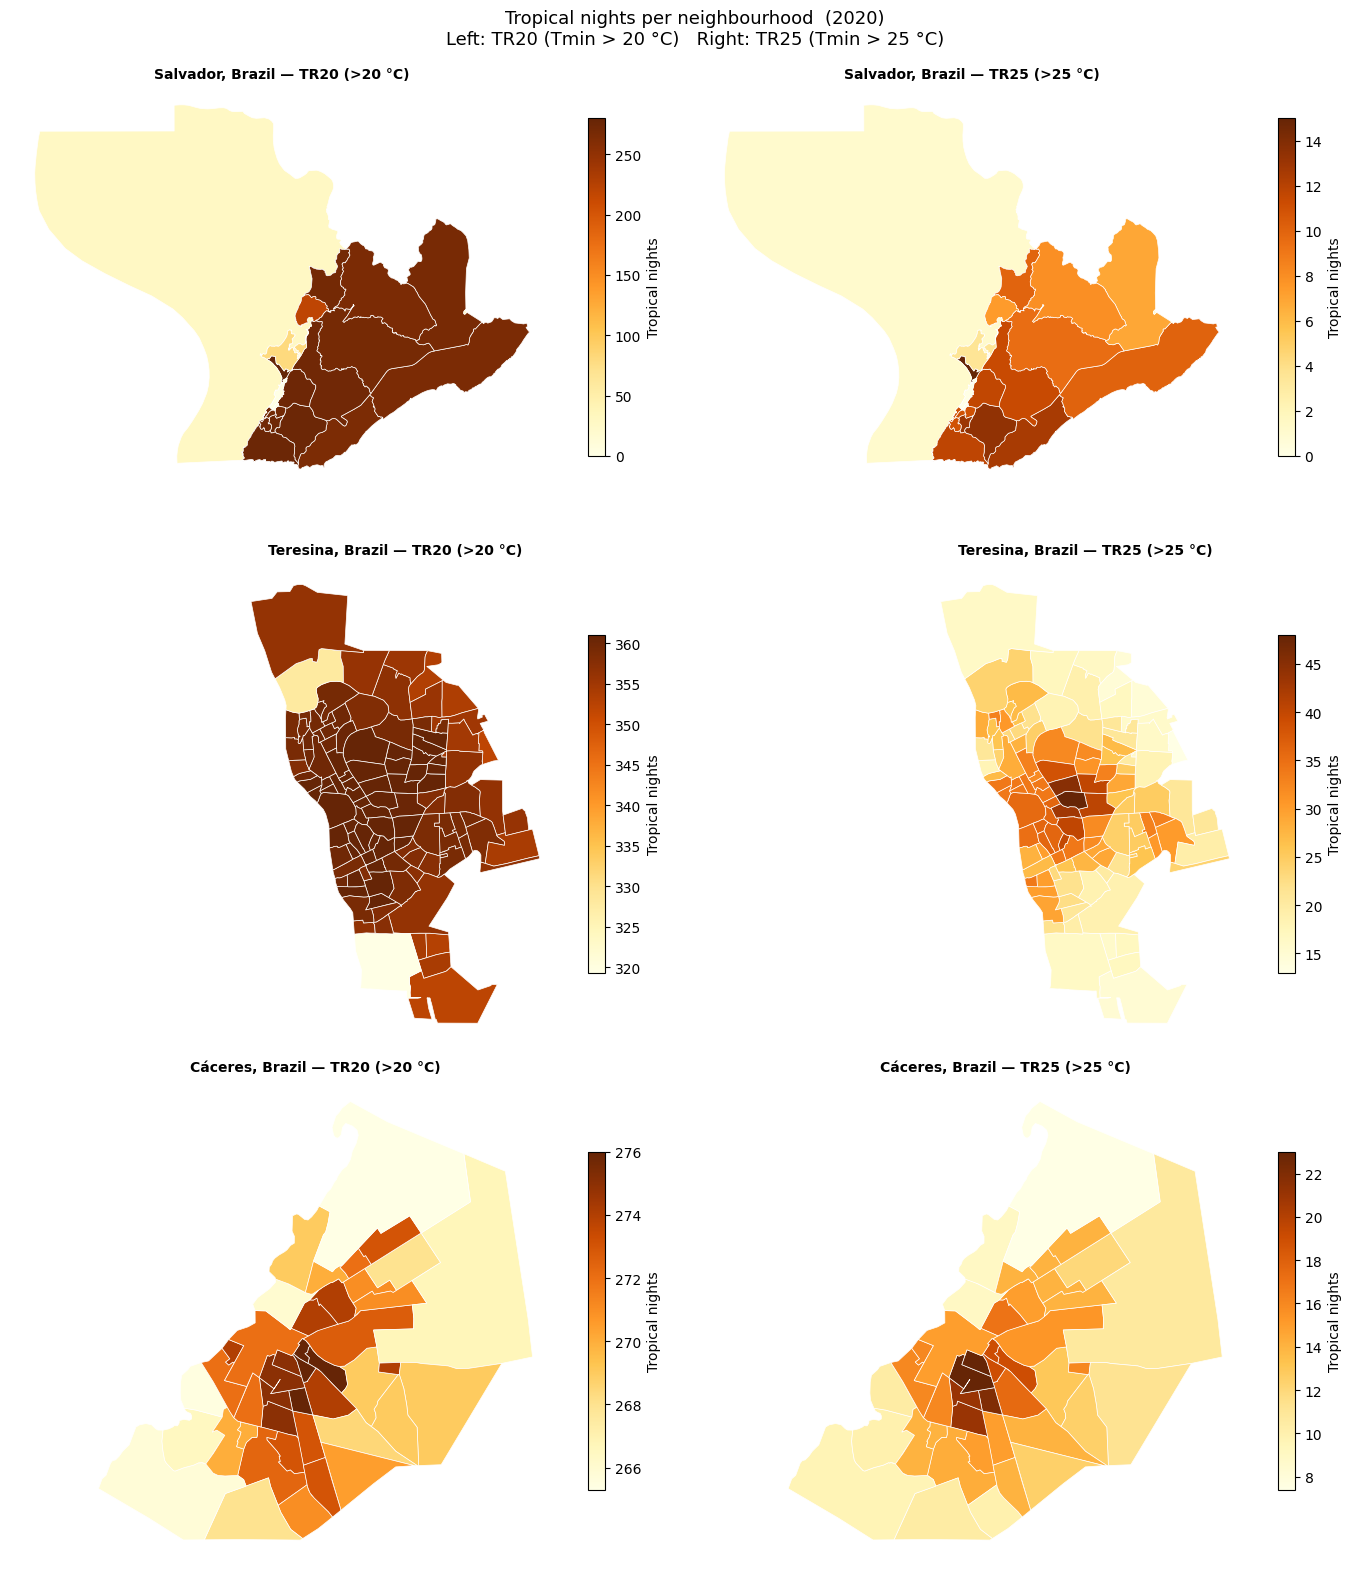

In [3]:
def tropical_nights_year(da, year, threshold):
    """Per-pixel count of tropical nights (Tmin > threshold) in a given year."""
    da_yr = da.sel(time=da.time.dt.year == year)
    return (da_yr > threshold).sum(dim='time').rename('tropical_nights')

# ---- Threshold comparison table ---------------------------------------------
thresh_rows = []
for c in CITY_KEYS:
    gdf = gdfs[c]
    for name, thr in THRESHOLDS.items():
        tn_map  = tropical_nights_year(tmins[c], DIAG_YEAR, thr)
        tn_nbhd = aggregate_to_neighbourhoods(tn_map, gdf, col='tn')
        vals    = tn_nbhd['tn'].dropna()
        cv      = vals.std() / vals.mean() if vals.mean() > 0 else 0
        thresh_rows.append({
            'City':             CITIES[c]['label'],
            'Threshold':        f'{name} (>{thr:.0f} °C)',
            'Mean nights (nbhd)': vals.mean(),
            'Min nights':       vals.min(),
            'Max nights':       vals.max(),
            'Range':            f"{vals.min():.0f}–{vals.max():.0f}",
            'CV':               cv,
            'Saturated?':       'YES' if cv < 0.05 else 'no',
        })

thresh_df = pd.DataFrame(thresh_rows)
display(
    thresh_df.style
    .format({'Mean nights (nbhd)': '{:.1f}', 'Min nights': '{:.0f}',
             'Max nights': '{:.0f}', 'CV': '{:.3f}', 'Range': '{}', 'Saturated?': '{}'})
    .background_gradient(subset=['CV'], cmap='RdYlGn', axis=None)
    .set_caption(
        f'Threshold saturation check ({DIAG_YEAR})  |  '
        'CV < 0.05 = spatially flat = no useful neighbourhood signal'
    )
    .set_table_styles(table_styles)
    .hide(axis='index')
)

# ---- Maps: tropical nights per neighbourhood --------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle(
    f'Tropical nights per neighbourhood  ({DIAG_YEAR})\n'
    'Left: TR20 (Tmin > 20 °C)   Right: TR25 (Tmin > 25 °C)',
    fontsize=13,
)

thr_items = list(THRESHOLDS.items())
for row, c in enumerate(CITY_KEYS):
    gdf   = gdfs[c]
    label = CITIES[c]['label']
    for col, (name, thr) in enumerate(thr_items):
        tn_map  = tropical_nights_year(tmins[c], DIAG_YEAR, thr)
        tn_nbhd = aggregate_to_neighbourhoods(tn_map, gdf, col='tn')
        plot_gdf = gdf.merge(tn_nbhd[['name', 'tn']], on='name', how='left')
        ax = axes[row][col]
        plot_gdf.plot(
            column='tn', ax=ax, cmap='YlOrBr',
            legend=True,
            legend_kwds={'label': 'Tropical nights', 'shrink': 0.7},
            edgecolor='white', linewidth=0.5,
            missing_kwds={'color': 'lightgrey'},
        )
        ax.set_title(f'{label} — {name} (>{thr:.0f} °C)', fontsize=10, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Build neighbourhood table: tropical nights + population + person-nights

For each city we construct a per-neighbourhood dataframe with:
- Population (2020)
- TR20 tropical nights (Tmin > 20 °C)
- TR25 tropical nights (Tmin > 25 °C)
- Person-nights for each threshold (nights × population)
- Ranks for all five columns

In [4]:
def build_nbhd_table(city_key, year):
    """Per-neighbourhood dataframe: population, tropical nights, person-nights, ranks."""
    da       = tmins[city_key]
    gdf      = gdfs[city_key]
    pop_grid = load_pop_grid(city_key, year)

    tr20_map = tropical_nights_year(da, year, 20.0)
    tr25_map = tropical_nights_year(da, year, 25.0)

    pop_nbhd  = aggregate_person_days_to_neighbourhoods(pop_grid, gdf, col='population')
    tr20_nbhd = aggregate_to_neighbourhoods(tr20_map, gdf, col='tr20_hd')
    tr25_nbhd = aggregate_to_neighbourhoods(tr25_map, gdf, col='tr25_hd')
    tr20_pd   = aggregate_person_days_to_neighbourhoods(
                    compute_person_days_map(tr20_map, pop_grid), gdf, col='tr20_pd')
    tr25_pd   = aggregate_person_days_to_neighbourhoods(
                    compute_person_days_map(tr25_map, pop_grid), gdf, col='tr25_pd')

    df = gdf[['name']].copy()
    df['population'] = pop_nbhd['population'].values
    df['tr20_hd']    = tr20_nbhd['tr20_hd'].values
    df['tr25_hd']    = tr25_nbhd['tr25_hd'].values
    df['tr20_pd']    = tr20_pd['tr20_pd'].values
    df['tr25_pd']    = tr25_pd['tr25_pd'].values

    for col in ['population', 'tr20_hd', 'tr25_hd', 'tr20_pd', 'tr25_pd']:
        df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)

    return df.dropna().reset_index(drop=True)

tables = {c: build_nbhd_table(c, DIAG_YEAR) for c in CITY_KEYS}

# Preview the Salvador table
print(f'Salvador neighbourhood table ({DIAG_YEAR}):')
display(
    tables['salvador'][[
        'name', 'population', 'tr20_hd', 'tr25_hd', 'tr20_pd', 'tr25_pd'
    ]].sort_values('tr20_pd', ascending=False)
    .head(10)
    .style
    .format({'population': '{:,.0f}', 'tr20_hd': '{:.1f}', 'tr25_hd': '{:.1f}',
             'tr20_pd': '{:,.0f}', 'tr25_pd': '{:,.0f}'})
    .background_gradient(subset=['tr20_hd', 'tr25_hd'], cmap='YlOrRd', axis=None)
    .set_table_styles(table_styles)
)

Salvador neighbourhood table (2020):


,name,population,tr20_hd,tr25_hd,tr20_pd,tr25_pd
6,São Caetano,"395,082",271.5,11.4,"106,930,985","4,388,892"
4,Pirajá,"371,435",268.4,9.5,"99,551,685","3,590,529"
0,Amaralina,"270,322",263.7,12.6,"70,973,530","3,336,447"
5,Santo Antônio,"195,988",274.1,11.6,"53,791,925","2,247,559"
20,Valéria,"184,514",265.7,7.9,"48,957,466","1,509,153"
1,Brotas,"177,034",275.1,13.4,"48,770,333","2,332,543"
3,Itapoã,"161,716",265.6,10.0,"44,345,627","1,604,990"
11,Paripe,"178,883",28.8,1.2,"39,193,759","1,571,587"
21,Vitória,"139,139",274.6,11.8,"38,258,311","1,616,064"
7,São Cristovão,"97,518",267.4,6.9,"26,526,596","890,043"


## Finding 1 — Person-night rankings are driven by population, not tropical-night counts

As in notebooks 07 and 07b, we test whether multiplying heat nights by population creates a metric that reflects *both* dimensions or whether population dominates.  The scatter below plots population rank against person-nights rank.  A diagonal line = perfect population dominance.

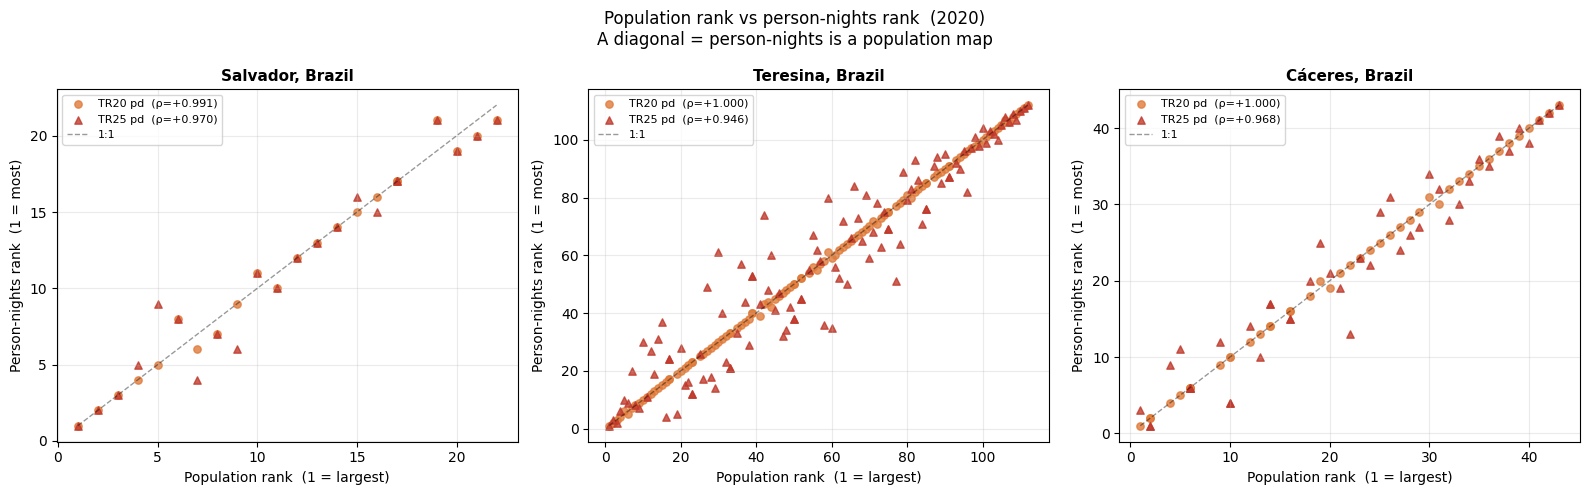

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Population rank vs person-nights rank  ({DIAG_YEAR})\n'
    'A diagonal = person-nights is a population map',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    df    = tables[c]
    n     = len(df)
    label = CITIES[c]['label']

    rho20, _ = spearmanr(df['rank_population'], df['rank_tr20_pd'])
    rho25, _ = spearmanr(df['rank_population'], df['rank_tr25_pd'])

    ax.scatter(df['rank_population'], df['rank_tr20_pd'],
               s=28, alpha=0.8, color='#e07b39',
               label=f'TR20 pd  (ρ={rho20:+.3f})')
    ax.scatter(df['rank_population'], df['rank_tr25_pd'],
               s=28, alpha=0.8, color='#c0392b', marker='^',
               label=f'TR25 pd  (ρ={rho25:+.3f})')
    ax.plot([1, n], [1, n], 'k--', linewidth=1, alpha=0.4, label='1:1')

    ax.set_xlabel('Population rank  (1 = largest)', fontsize=10)
    ax.set_ylabel('Person-nights rank  (1 = most)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Summary statistics — all three cities

The table below captures CVs and Spearman correlations for the tropical-night metrics.  Compare with the equivalent tables in notebooks 07 (TX90p) and 07b (TN90p) to see whether absolute nighttime thresholds provide more or less spatial discrimination than relative ones.

In [6]:
rows = []
for c in CITY_KEYS:
    df = tables[c]

    def safe_cv(col):
        m = df[col].mean()
        return df[col].std() / m if m > 0 else np.nan

    rho_pop_tr20pd, _ = spearmanr(df['population'], df['tr20_pd'])
    rho_pop_tr25pd, _ = spearmanr(df['population'], df['tr25_pd'])
    rho_tr20hd_pd,  _ = spearmanr(df['tr20_hd'],   df['tr20_pd'])
    rho_tr25hd_pd,  _ = spearmanr(df['tr25_hd'],   df['tr25_pd'])
    rho_tr20_tr25,  _ = spearmanr(df['tr20_hd'],   df['tr25_hd'])
    rho_pd_tr20_25, _ = spearmanr(df['tr20_pd'],   df['tr25_pd'])

    rows.append({
        'City':                  CITIES[c]['label'],
        'CV: population':        safe_cv('population'),
        'CV: TR20 nights':       safe_cv('tr20_hd'),
        'CV: TR25 nights':       safe_cv('tr25_hd'),
        'TR20 range':            f"{df['tr20_hd'].min():.0f}–{df['tr20_hd'].max():.0f} nights",
        'TR25 range':            f"{df['tr25_hd'].min():.0f}–{df['tr25_hd'].max():.0f} nights",
        'ρ pop vs TR20 pd':      rho_pop_tr20pd,
        'ρ pop vs TR25 pd':      rho_pop_tr25pd,
        'ρ TR20 hd vs TR20 pd':  rho_tr20hd_pd,
        'ρ TR25 hd vs TR25 pd':  rho_tr25hd_pd,
        'ρ TR20 vs TR25 nights': rho_tr20_tr25,
        'ρ TR20 pd vs TR25 pd':  rho_pd_tr20_25,
    })

summary = pd.DataFrame(rows).set_index('City')

cv_cols  = ['CV: population', 'CV: TR20 nights', 'CV: TR25 nights']
rho_cols = [
    'ρ pop vs TR20 pd', 'ρ pop vs TR25 pd',
    'ρ TR20 hd vs TR20 pd', 'ρ TR25 hd vs TR25 pd',
    'ρ TR20 vs TR25 nights', 'ρ TR20 pd vs TR25 pd',
]
str_cols = ['TR20 range', 'TR25 range']

fmt = {c: '{:.3f}' for c in cv_cols + rho_cols}
fmt.update({c: '{}' for c in str_cols})

display(
    summary.style
    .format(fmt)
    .background_gradient(subset=cv_cols,  cmap='YlOrRd', axis=None)
    .background_gradient(subset=rho_cols, cmap='RdYlGn', axis=None, vmin=-1, vmax=1)
    .set_caption(
        f'Neighbourhood-level summary  ({DIAG_YEAR})  |  '
        'CV = coefficient of variation  |  ρ = Spearman rank correlation'
    )
    .set_table_styles(table_styles)
)

,CV: population,CV: TR20 nights,CV: TR25 nights,TR20 range,TR25 range,ρ pop vs TR20 pd,ρ pop vs TR25 pd,ρ TR20 hd vs TR20 pd,ρ TR25 hd vs TR25 pd,ρ TR20 vs TR25 nights,ρ TR20 pd vs TR25 pd
City,,,,,,,,,,,
"Salvador, Brazil",1.041,0.433,0.473,0–280 nights,0–15 nights,0.991,0.970,0.216,0.347,0.875,0.982
"Teresina, Brazil",0.878,0.015,0.276,319–361 nights,13–48 nights,1.000,0.946,0.103,0.318,0.782,0.946
"Cáceres, Brazil",0.506,0.012,0.263,265–276 nights,7–23 nights,1.000,0.968,0.580,0.803,0.920,0.969


## Finding 2 — Decomposing population dominance (three panels per city)

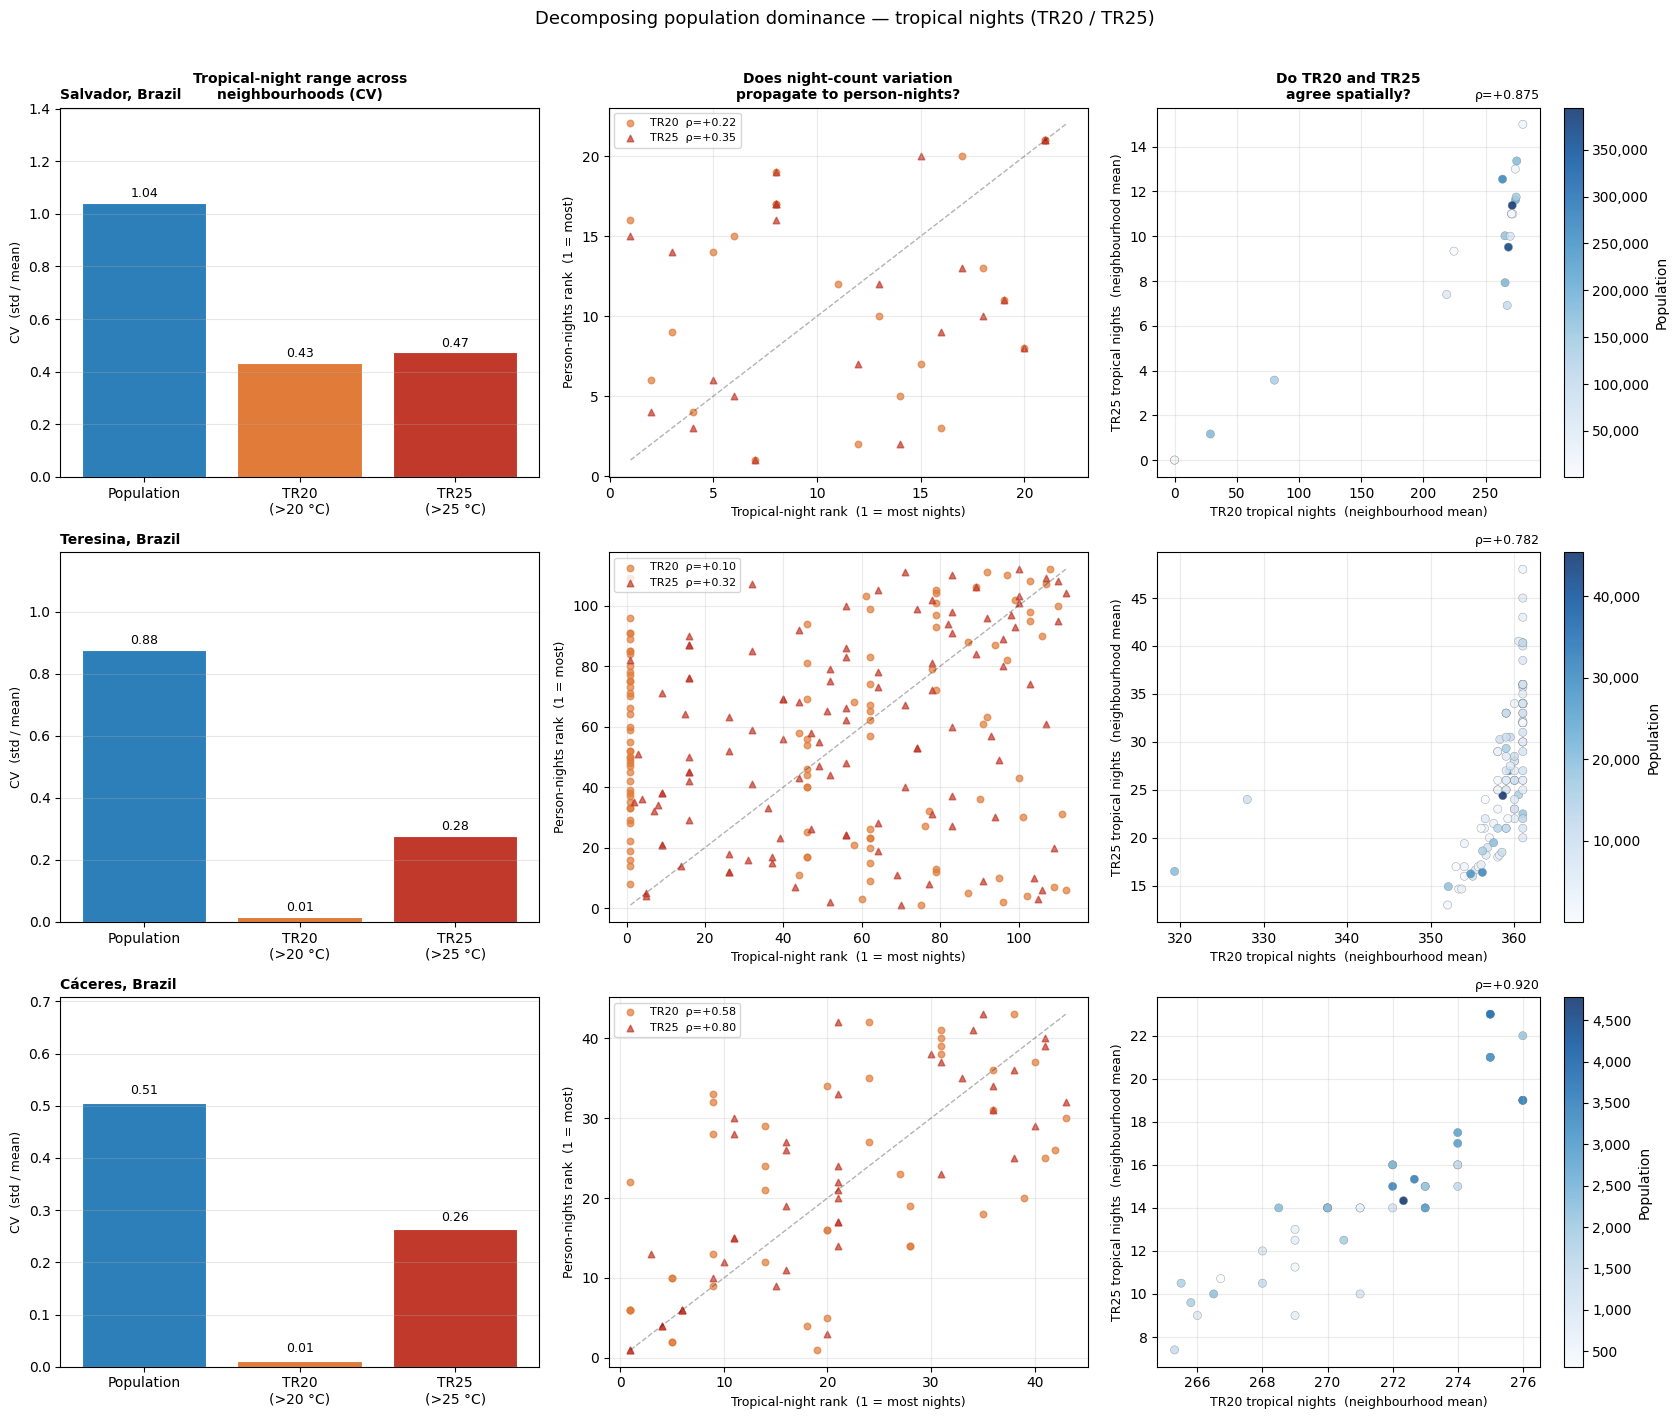

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(17, 14))
fig.suptitle(
    'Decomposing population dominance — tropical nights (TR20 / TR25)',
    fontsize=13, y=1.01,
)

panel_titles = [
    'Tropical-night range across\nneighbourhoods (CV)',
    'Does night-count variation\npropagate to person-nights?',
    'Do TR20 and TR25\nagree spatially?',
]
for ax, t in zip(axes[0], panel_titles):
    ax.set_title(t, fontsize=10, fontweight='bold')

for row, c in enumerate(CITY_KEYS):
    df    = tables[c]
    label = CITIES[c]['label']
    n     = len(df)

    def safe_cv(col):
        m = df[col].mean()
        return df[col].std() / m if m > 0 else 0.0

    # ---- Panel 1: CV bar chart -----------------------------------------------
    ax = axes[row][0]
    cv_vals = [safe_cv('population'), safe_cv('tr20_hd'), safe_cv('tr25_hd')]
    bars = ax.bar(
        ['Population', 'TR20\n(>20 °C)', 'TR25\n(>25 °C)'],
        cv_vals,
        color=['#2c7fb8', '#e07b39', '#c0392b'],
        edgecolor='white', linewidth=0.8,
    )
    for bar, v in zip(bars, cv_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('CV  (std / mean)', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(0, max(cv_vals) * 1.3 + 0.05)

    # ---- Panel 2: night-count rank vs person-nights rank --------------------
    ax = axes[row][1]
    rho20, _ = spearmanr(df['rank_tr20_hd'], df['rank_tr20_pd'])
    rho25, _ = spearmanr(df['rank_tr25_hd'], df['rank_tr25_pd'])
    ax.scatter(df['rank_tr20_hd'], df['rank_tr20_pd'],
               s=22, alpha=0.7, color='#e07b39',
               label=f'TR20  ρ={rho20:+.2f}')
    ax.scatter(df['rank_tr25_hd'], df['rank_tr25_pd'],
               s=22, alpha=0.7, color='#c0392b', marker='^',
               label=f'TR25  ρ={rho25:+.2f}')
    ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.3)
    ax.set_xlabel('Tropical-night rank  (1 = most nights)', fontsize=9)
    ax.set_ylabel('Person-nights rank  (1 = most)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    # ---- Panel 3: TR20 vs TR25 scatter, coloured by population ---------------
    ax = axes[row][2]
    rho_hd, _ = spearmanr(df['tr20_hd'], df['tr25_hd'])
    sc = ax.scatter(
        df['tr20_hd'], df['tr25_hd'],
        c=df['population'], cmap='Blues',
        s=35, alpha=0.85, edgecolors='grey', linewidth=0.3,
    )
    plt.colorbar(sc, ax=ax, label='Population',
                 format=mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlabel('TR20 tropical nights  (neighbourhood mean)', fontsize=9)
    ax.set_ylabel('TR25 tropical nights  (neighbourhood mean)', fontsize=9)
    ax.set_title(f'ρ={rho_hd:+.3f}', fontsize=9, loc='right')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Interpretation

**Column 1 — CV comparison.**  Where population CV >> tropical-night CV, the person-nights product is dominated by population and person-nights maps become population maps.

**Column 2 — Does night-count variation propagate to person-nights?**  If tropical nights drove person-night rankings the scatter would lie on the diagonal.  A flat cloud means night-count variation has been erased by population.

**Column 3 — Do TR20 and TR25 agree spatially?**  Both thresholds should flag the same neighbourhoods if they measure the same underlying phenomenon; a flat or negative slope indicates threshold saturation (all neighbourhoods have many TR20 nights, so TR20 provides no relative information).

In [8]:
from IPython.display import Markdown

_SAT  = 0.05   # CV below this = threshold saturated
_ANTI = -0.20  # ρ below this = spatially anti-correlated

def _mechanism_text(c):
    df    = tables[c]
    label = CITIES[c]['label']

    def safe_cv(col):
        m = df[col].mean()
        return df[col].std() / m if m > 0 else 0.0

    cv_pop  = safe_cv('population')
    cv_tr20 = safe_cv('tr20_hd')
    cv_tr25 = safe_cv('tr25_hd')

    rho_pop_tr20, _ = spearmanr(df['population'], df['tr20_pd'])
    rho_pop_tr25, _ = spearmanr(df['population'], df['tr25_pd'])
    rho_tr20_tr25,_ = spearmanr(df['tr20_hd'],    df['tr25_hd'])

    lo20, hi20 = df['tr20_hd'].min(), df['tr20_hd'].max()
    lo25, hi25 = df['tr25_hd'].min(), df['tr25_hd'].max()

    parts = [f'**{label}**']

    for name, cv, lo, hi, rho_pop in [
        ('TR20 (>20 °C)', cv_tr20, lo20, hi20, rho_pop_tr20),
        ('TR25 (>25 °C)', cv_tr25, lo25, hi25, rho_pop_tr25),
    ]:
        if cv < _SAT:
            parts.append(
                f'**{name}** is saturated: tropical nights range only {lo:.0f}–{hi:.0f} '
                f'across neighbourhoods (CV = {cv:.2f}).  '
                f'Person-nights ≈ population × constant (ρ(pop, pd) = {rho_pop:+.3f}).'
            )
        else:
            ratio = cv_pop / cv if cv > 0 else float('inf')
            parts.append(
                f'**{name}** shows spatial variation (range {lo:.0f}–{hi:.0f} nights, CV = {cv:.2f}), '
                f'but population CV = {cv_pop:.2f} is {ratio:.1f}× larger — '
                f'person-nights remain population-driven (ρ(pop, pd) = {rho_pop:+.3f}).'
            )

    if rho_tr20_tr25 < _ANTI:
        parts.append(
            f'The two thresholds are **spatially anti-correlated** (ρ(TR20, TR25) = {rho_tr20_tr25:+.3f}): '
            f'the neighbourhoods with the most TR20 nights tend to have the fewest TR25 exceedances, '
            f'suggesting persistent warmth drives TR20 saturation.'
        )
    elif rho_tr20_tr25 > 0.70:
        parts.append(
            f'Both thresholds agree spatially (ρ(TR20, TR25) = {rho_tr20_tr25:+.3f}): '
            f'the same neighbourhoods are warm by both definitions.'
        )
    else:
        parts.append(
            f'The two thresholds show moderate spatial agreement (ρ(TR20, TR25) = {rho_tr20_tr25:+.3f}).'
        )

    return '\n\n'.join(parts)


city_block = '\n\n---\n\n'.join(_mechanism_text(c) for c in CITY_KEYS)

display(Markdown(f"""
### City-specific findings

{city_block}

---

### Cross-notebook comparison

Place the quadrant plots below alongside those in notebook 07 (TX90p daytime) and 07b (TN90p relative) to identify neighbourhoods that face **both daytime heat and warm nights** — these face the highest combined physiological stress.
"""))


### City-specific findings

**Salvador, Brazil**

**TR20 (>20 °C)** shows spatial variation (range 0–280 nights, CV = 0.43), but population CV = 1.04 is 2.4× larger — person-nights remain population-driven (ρ(pop, pd) = +0.991).

**TR25 (>25 °C)** shows spatial variation (range 0–15 nights, CV = 0.47), but population CV = 1.04 is 2.2× larger — person-nights remain population-driven (ρ(pop, pd) = +0.970).

Both thresholds agree spatially (ρ(TR20, TR25) = +0.875): the same neighbourhoods are warm by both definitions.

---

**Teresina, Brazil**

**TR20 (>20 °C)** is saturated: tropical nights range only 319–361 across neighbourhoods (CV = 0.01).  Person-nights ≈ population × constant (ρ(pop, pd) = +1.000).

**TR25 (>25 °C)** shows spatial variation (range 13–48 nights, CV = 0.28), but population CV = 0.88 is 3.2× larger — person-nights remain population-driven (ρ(pop, pd) = +0.946).

Both thresholds agree spatially (ρ(TR20, TR25) = +0.782): the same neighbourhoods are warm by both definitions.

---

**Cáceres, Brazil**

**TR20 (>20 °C)** is saturated: tropical nights range only 265–276 across neighbourhoods (CV = 0.01).  Person-nights ≈ population × constant (ρ(pop, pd) = +1.000).

**TR25 (>25 °C)** shows spatial variation (range 7–23 nights, CV = 0.26), but population CV = 0.51 is 1.9× larger — person-nights remain population-driven (ρ(pop, pd) = +0.968).

Both thresholds agree spatially (ρ(TR20, TR25) = +0.920): the same neighbourhoods are warm by both definitions.

---

### Cross-notebook comparison

Place the quadrant plots below alongside those in notebook 07 (TX90p daytime) and 07b (TN90p relative) to identify neighbourhoods that face **both daytime heat and warm nights** — these face the highest combined physiological stress.


## Quadrant classification: tropical nights × population

Quadrant boundaries are set at the **city median** for each dimension.  Point size is proportional to person-nights (total burden in the neighbourhood).

| Quadrant | Interpretation | Suggested action |
|---|---|---|
| **Hot + Dense** | Highest overnight burden; greatest intervention impact | Priority cooling infrastructure, night-time heat plans |
| **Hot + Sparse** | Elevated risk per person; fewer beneficiaries | Heat health surveillance, early warning |
| **Cool + Dense** | Large population, fewer warm nights | Monitor; lower immediate priority |
| **Cool + Sparse** | Low overnight burden | Baseline |

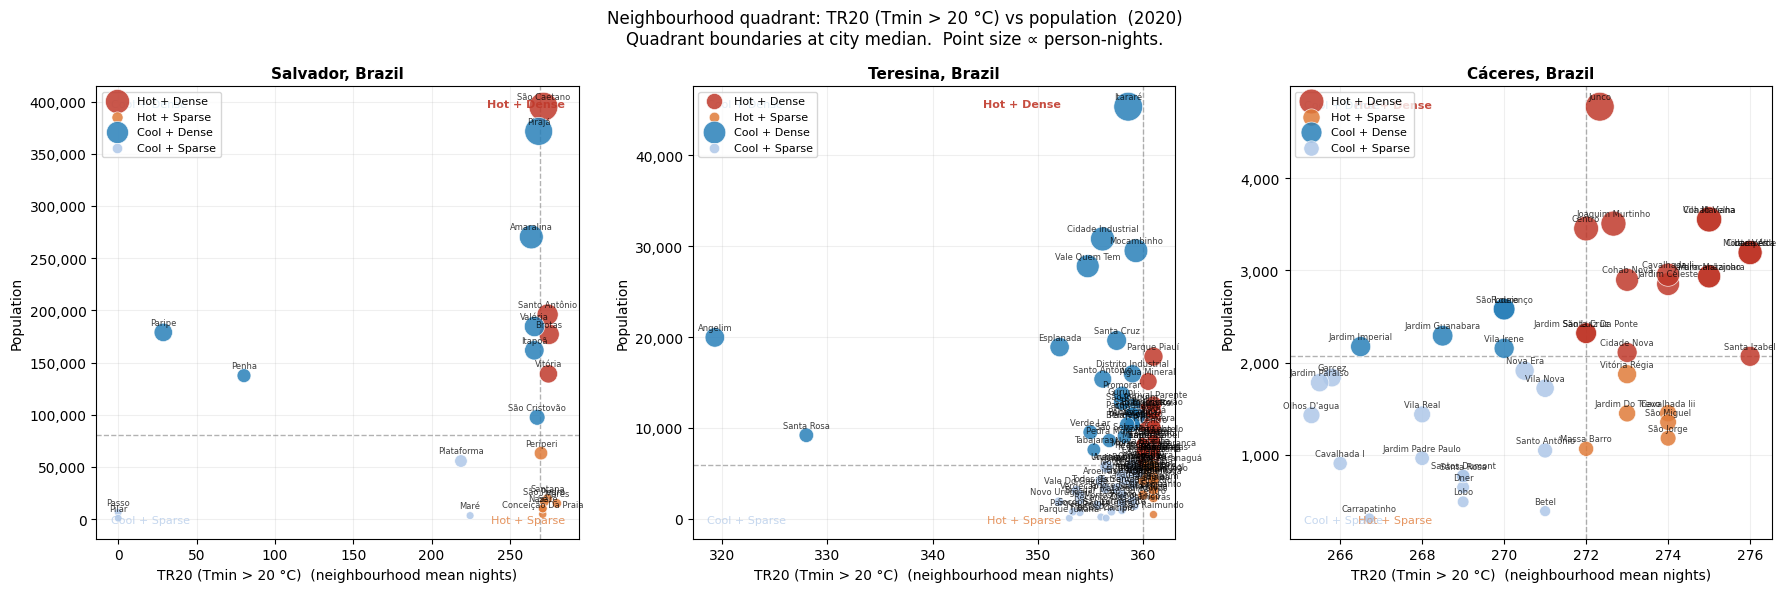


Neighbourhoods per quadrant  (2020, TR20 (Tmin > 20 °C))

--- Salvador, Brazil ---


,N neighbourhoods,Total population,Mean tropical nights,Total person-nights
quadrant,,,,
Hot + Dense,4,"907,244",273.8,"247,751,553"
Hot + Sparse,7,"139,313",272.7,"38,042,120"
Cool + Dense,7,"1,401,837",205.7,"348,294,720"
Cool + Sparse,4,"66,434",110.9,"14,391,811"


--- Teresina, Brazil ---


,N neighbourhoods,Total population,Mean tropical nights,Total person-nights
quadrant,,,,
Hot + Dense,33,"296,036",360.7,"106,782,622"
Hot + Sparse,24,"98,304",360.9,"35,474,678"
Cool + Dense,23,"370,917",354.6,"132,351,532"
Cool + Sparse,32,"92,759",356.9,"33,192,598"


--- Cáceres, Brazil ---


,N neighbourhoods,Total population,Mean tropical nights,Total person-nights
quadrant,,,,
Hot + Dense,17,"51,817",274.1,"14,207,425"
Hot + Sparse,6,"8,373",273.3,"2,288,679"
Cool + Dense,5,"11,780",269.0,"3,171,404"
Cool + Sparse,15,"16,418",268.3,"4,409,546"


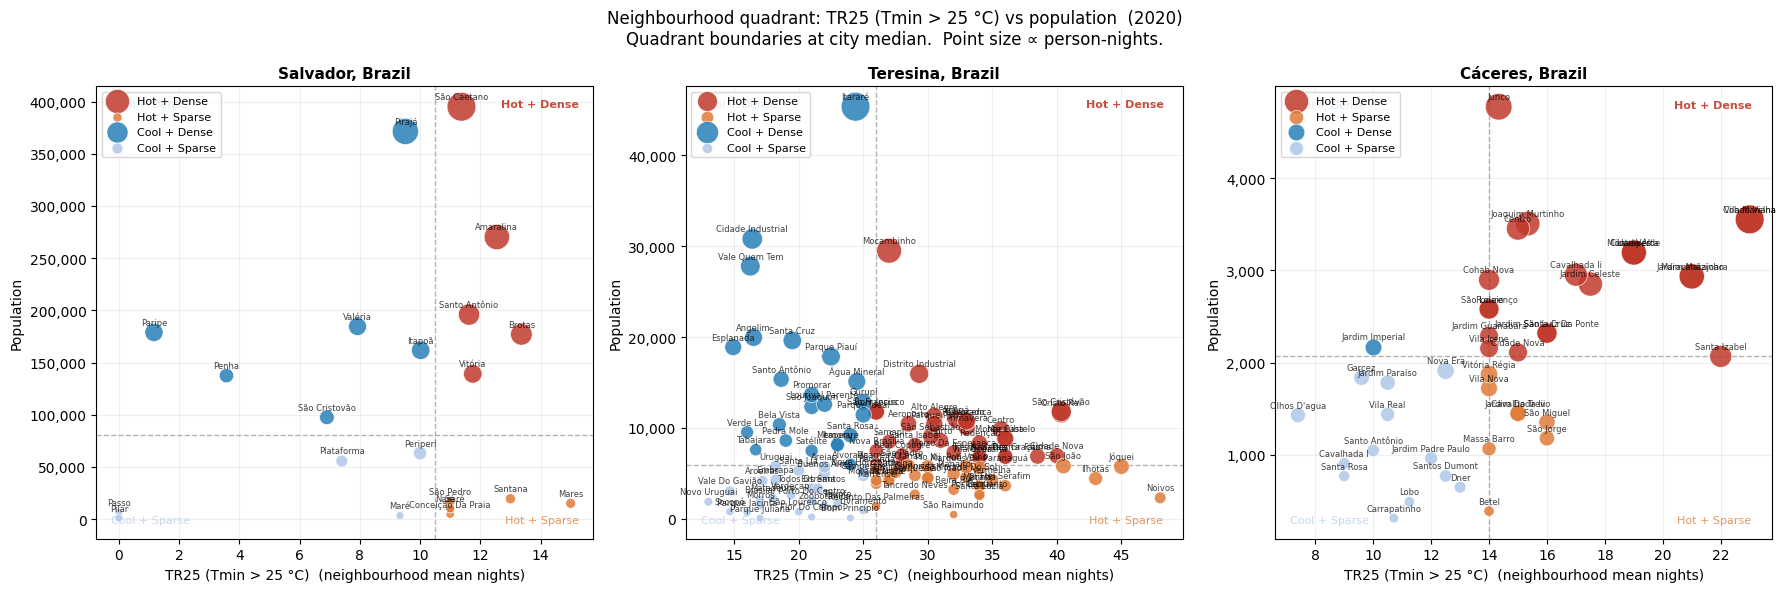


Neighbourhoods per quadrant  (2020, TR25 (Tmin > 25 °C))

--- Salvador, Brazil ---


,N neighbourhoods,Total population,Mean tropical nights,Total person-nights
quadrant,,,,
Hot + Dense,5,"1,177,565",12.1,"13,921,504"
Hot + Sparse,6,"76,119",12.0,"936,737"
Cool + Dense,6,"1,131,515",6.5,"10,005,729"
Cool + Sparse,5,"129,628",5.3,"1,173,267"


--- Teresina, Brazil ---


,N neighbourhoods,Total population,Mean tropical nights,Total person-nights
quadrant,,,,
Hot + Dense,33,"318,473",32.2,"10,093,078"
Hot + Sparse,30,"122,566",32.5,"4,014,886"
Cool + Dense,23,"348,479",20.6,"7,143,751"
Cool + Sparse,26,"68,497",19.7,"1,428,668"


--- Cáceres, Brazil ---


,N neighbourhoods,Total population,Mean tropical nights,Total person-nights
quadrant,,,,
Hot + Dense,21,"61,423",17.3,"1,077,590"
Hot + Sparse,8,"10,484",14.8,"154,743"
Cool + Dense,1,"2,174",10.0,"23,385"
Cool + Sparse,13,"14,307",10.6,"160,454"


In [9]:
QUADRANT_COLORS = {
    'Hot + Dense':   '#c0392b',
    'Hot + Sparse':  '#e07b39',
    'Cool + Dense':  '#2980b9',
    'Cool + Sparse': '#aec7e8',
}

def assign_quadrant(hd, pop, hd_med, pop_med):
    hot   = hd  >= hd_med
    dense = pop >= pop_med
    if hot and dense:   return 'Hot + Dense'
    if hot:             return 'Hot + Sparse'
    if dense:           return 'Cool + Dense'
    return 'Cool + Sparse'

for thr_name, hd_col, pd_col in [
    ('TR20 (Tmin > 20 °C)', 'tr20_hd', 'tr20_pd'),
    ('TR25 (Tmin > 25 °C)', 'tr25_hd', 'tr25_pd'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f'Neighbourhood quadrant: {thr_name} vs population  ({DIAG_YEAR})\n'
        'Quadrant boundaries at city median.  Point size ∝ person-nights.',
        fontsize=12,
    )

    for ax, c in zip(axes, CITY_KEYS):
        df      = tables[c].copy()
        label   = CITIES[c]['label']
        hd_med  = df[hd_col].median()
        pop_med = df['population'].median()

        df['quadrant'] = df.apply(
            lambda r: assign_quadrant(r[hd_col], r['population'], hd_med, pop_med), axis=1
        )

        pd_norm = (df[pd_col] / df[pd_col].max()) * 400 + 30

        for q, color in QUADRANT_COLORS.items():
            mask = df['quadrant'] == q
            ax.scatter(
                df.loc[mask, hd_col], df.loc[mask, 'population'],
                s=pd_norm[mask], color=color, alpha=0.85,
                edgecolors='white', linewidth=0.5, label=q, zorder=3,
            )

        for _, row in df.iterrows():
            ax.annotate(
                row['name'], (row[hd_col], row['population']),
                fontsize=6, alpha=0.75, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points',
            )

        ax.axvline(hd_med,  color='grey', linewidth=1, linestyle='--', alpha=0.6)
        ax.axhline(pop_med, color='grey', linewidth=1, linestyle='--', alpha=0.6)

        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        ax.text(xlim[1] * 0.97, ylim[1] * 0.97, 'Hot + Dense',
                ha='right', va='top', fontsize=8, color='#c0392b',
                fontweight='bold', alpha=0.9)
        ax.text(xlim[1] * 0.97, ylim[0] + (ylim[1]-ylim[0])*0.03, 'Hot + Sparse',
                ha='right', va='bottom', fontsize=8, color='#e07b39', alpha=0.8)
        ax.text(xlim[0] + (xlim[1]-xlim[0])*0.03, ylim[1]*0.97, 'Cool + Dense',
                ha='left', va='top', fontsize=8, color='#2980b9', alpha=0.7)
        ax.text(xlim[0] + (xlim[1]-xlim[0])*0.03, ylim[0] + (ylim[1]-ylim[0])*0.03,
                'Cool + Sparse', ha='left', va='bottom', fontsize=8,
                color='#aec7e8', alpha=0.7)

        ax.set_xlabel(f'{thr_name}  (neighbourhood mean nights)', fontsize=10)
        ax.set_ylabel('Population', fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # ---- Per-quadrant summary table ----------------------------------------
    print(f'\nNeighbourhoods per quadrant  ({DIAG_YEAR}, {thr_name})\n')
    for c in CITY_KEYS:
        df = tables[c].copy()
        hd_med  = df[hd_col].median()
        pop_med = df['population'].median()
        df['quadrant'] = df.apply(
            lambda r: assign_quadrant(r[hd_col], r['population'], hd_med, pop_med), axis=1
        )
        counts = df.groupby('quadrant').agg(
            n=('name', 'count'),
            total_pop=('population', 'sum'),
            mean_nights=(hd_col, 'mean'),
            total_pd=(pd_col, 'sum'),
        ).reindex(QUADRANT_COLORS.keys()).fillna(0)
        counts.columns = [
            'N neighbourhoods', 'Total population',
            'Mean tropical nights', 'Total person-nights'
        ]
        print(f'--- {CITIES[c]["label"]} ---')
        display(counts.style.format({
            'N neighbourhoods':    '{:.0f}',
            'Total population':    '{:,.0f}',
            'Mean tropical nights':'{:.1f}',
            'Total person-nights': '{:,.0f}',
        }).bar(subset=['Total person-nights'], color='#c0392b', vmin=0))

## Cross-threshold summary: does TR25 add information over TR20?

The 25 °C threshold is more selective than 20 °C.  In cities where nearly every night exceeds 20 °C (TR20 saturated), TR25 may still provide spatial discrimination.  The table below compares the two rankings.

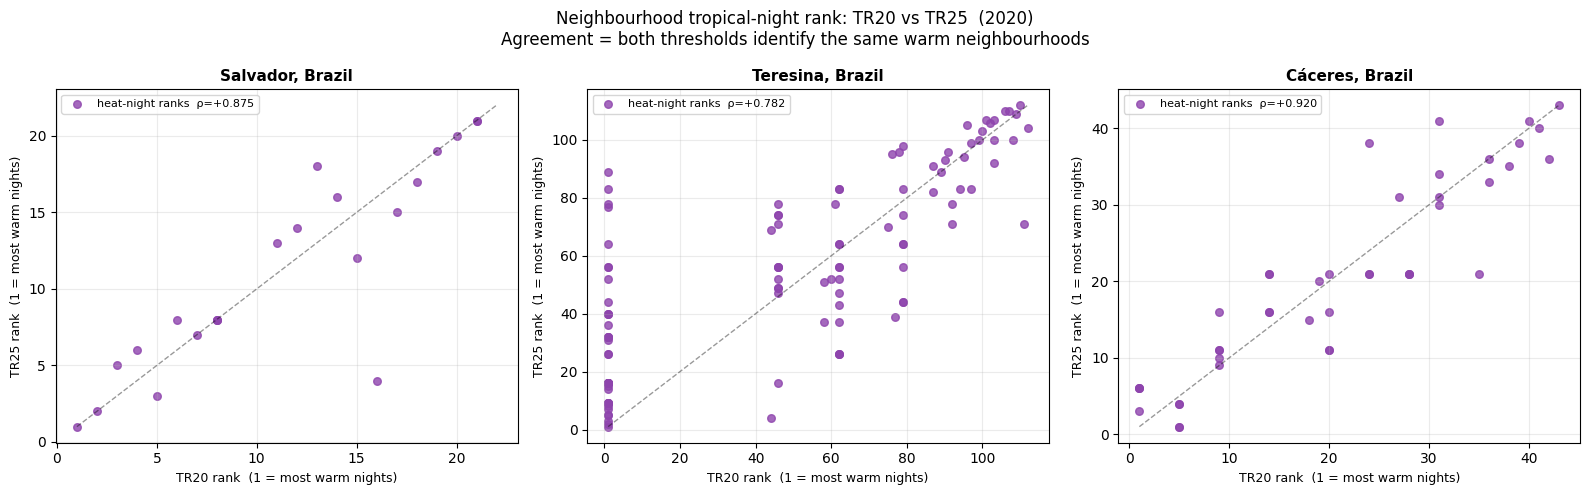

,CV: TR20 nights,CV: TR25 nights,ρ (TR20 vs TR25 hd),ρ (TR20 vs TR25 pd),TR25 adds info?
City,,,,,
"Salvador, Brazil",0.433,0.473,0.875,0.982,no — same neighbourhoods
"Teresina, Brazil",0.015,0.276,0.782,0.946,no — same neighbourhoods
"Cáceres, Brazil",0.012,0.263,0.920,0.969,no — same neighbourhoods


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Neighbourhood tropical-night rank: TR20 vs TR25  ({DIAG_YEAR})\n'
    'Agreement = both thresholds identify the same warm neighbourhoods',
    fontsize=12,
)

comparison_rows = []
for ax, c in zip(axes, CITY_KEYS):
    df    = tables[c]
    n     = len(df)
    label = CITIES[c]['label']

    rho_hd, _  = spearmanr(df['tr20_hd'],   df['tr25_hd'])
    rho_pd, _  = spearmanr(df['tr20_pd'],   df['tr25_pd'])

    def safe_cv(col):
        m = df[col].mean()
        return df[col].std() / m if m > 0 else 0.0

    comparison_rows.append({
        'City':                CITIES[c]['label'],
        'CV: TR20 nights':     safe_cv('tr20_hd'),
        'CV: TR25 nights':     safe_cv('tr25_hd'),
        'ρ (TR20 vs TR25 hd)': rho_hd,
        'ρ (TR20 vs TR25 pd)': rho_pd,
        'TR25 adds info?':     'YES — different rankings' if abs(rho_hd) < 0.70 else 'no — same neighbourhoods',
    })

    ax.scatter(df['rank_tr20_hd'], df['rank_tr25_hd'],
               s=30, alpha=0.8, color='#8e44ad',
               label=f'heat-night ranks  ρ={rho_hd:+.3f}')
    ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.4)
    ax.set_xlabel('TR20 rank  (1 = most warm nights)', fontsize=9)
    ax.set_ylabel('TR25 rank  (1 = most warm nights)', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

comp_df = pd.DataFrame(comparison_rows).set_index('City')
display(
    comp_df.style
    .format({'CV: TR20 nights': '{:.3f}', 'CV: TR25 nights': '{:.3f}',
             'ρ (TR20 vs TR25 hd)': '{:.3f}', 'ρ (TR20 vs TR25 pd)': '{:.3f}',
             'TR25 adds info?': '{}'})
    .background_gradient(
        subset=['ρ (TR20 vs TR25 hd)', 'ρ (TR20 vs TR25 pd)'],
        cmap='RdYlGn', axis=None, vmin=-1, vmax=1,
    )
    .set_caption(
        'Does TR25 identify different neighbourhoods from TR20?  '
        'ρ < 0.70 = meaningfully different rankings'
    )
    .set_table_styles(table_styles)
)

## Conclusions

### Tropical nights as a hazard metric

1. **Threshold saturation is the core limitation in hot cities.**  In Teresina and Cáceres, where Tmin routinely exceeds 20 °C, TR20 is likely crossed on nearly every night of the year and carries no spatial signal (CV ≈ 0).  TR25 is more selective and may recover some spatial discrimination.

2. **Where TR20 works (Salvador-type).**  In cities with more variability in nighttime temperature — typically coastal, episodic, or higher-elevation cities — TR20 tropical nights can vary meaningfully across neighbourhoods and provide useful hazard ranking.

3. **Person-nights replicate the population-dominance problem from notebooks 07/07b.**  Regardless of which tropical-night threshold is used, multiplying by population at 1 km intra-city resolution produces rankings that are essentially population maps (ρ ≈ +0.97–1.00).

4. **Tropical nights vs TN90p.**  TR20 and TR25 are absolute thresholds — they answer "does the body have a cool recovery window?"  TN90p is relative — it answers "is tonight unusually warm for this location?"  The EHF(Tmin) metric explored in notebook 13 combines both ideas through the acclimatisation component.  For neighbourhood discrimination in chronically hot cities, EHF(Tmin) magnitude outperforms all three nighttime metrics.

### Recommendation for developers

| Metric | Best use case | Limitation |
|---|---|---|
| TR20 (Tmin > 20 °C) | Episodic/coastal cities; absolute physiological grounding; communication | Saturates in hot cities; CV ≈ 0 in Teresina/Cáceres |
| TR25 (Tmin > 25 °C) | More selective; better in hot cities than TR20 | Still likely to saturate in the hottest cities |
| TN90p | Literature-standard relative metric; cross-city comparable | Normalises out the absolute heat signal; low CV everywhere at 1 km |
| EHF(Tmin) magnitude | Best neighbourhood discrimination in all climate regimes | Requires both Tmax and Tmin; less intuitive to communicate |

**Practical suggestion:** expose TR20 tropical-night counts in the platform UI as a communication metric ("X nights above 20 °C per year") alongside the EHF(Tmin) ranking.  The absolute count is easy to understand; the EHF ranking provides the analytically reliable spatial discrimination.

## Resolution check: UrbClim 100 m Tmin vs GSHTD 1 km

The low CV values for TR20 in Teresina and Cáceres, and the modest CV in Salvador, may partly reflect a **data resolution limitation** rather than a property of the metric itself.  The nocturnal UHI — the mechanism that creates within-city Tmin variation — operates at scales of 50–200 m (building density, canyon geometry, vegetation cover).  At 1 km, these gradients are smoothed into the background.

Notebook 08 showed that for Tmax, absolute heat-day CV jumped from **0.443 → 0.815** when moving from 1 km GSHTD to 100 m UrbClim.  TX90p (a relative threshold) got *worse* at 100 m because it normalises out the very signal resolution reveals.  Tropical nights use an **absolute** threshold and should therefore benefit from higher resolution in the same way as absolute Tmax heat days.

UrbClim provides daily minimum temperature (`T2M_year_daily_min_YYYY.nc`) at 100 m for Salvador 2008–2017, allowing a direct test.  We replicate the CV and person-nights analysis on Tmin at 100 m and compare directly with the 1 km results above.

Found 10 UrbClim Tmin files
Shape : {'time': 3653, 'y': 201, 'x': 201}
Period: 2008-01-01 to 2017-12-31
Tmin range: 18.8 – 28.5 °C

UrbClim 100 m  (2008–2017 mean):
  TR20: min=359.4  max=365.3  CV=0.001
  TR25: min=10.0  max=218.5  CV=0.410
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg

UrbClim 100 m neighbourhood stats  (2017):
  TR20 neighbourhood: mean=365.0  range=365–365  CV=0.000
  TR25 neighbourhood: mean=145.9  range=58–206  CV=0.295


,CV: population,CV: TR20 nights,CV: TR25 nights,Ratio CV(TR20)/CV(pop),ρ pop vs TR20 pd,ρ pop vs TR25 pd
Dataset,,,,,,
GSHTD 1 km,1.041,0.433,0.473,0.416,0.991,0.970
UrbClim 100 m,1.211,0.000,0.295,0.000,1.000,0.987


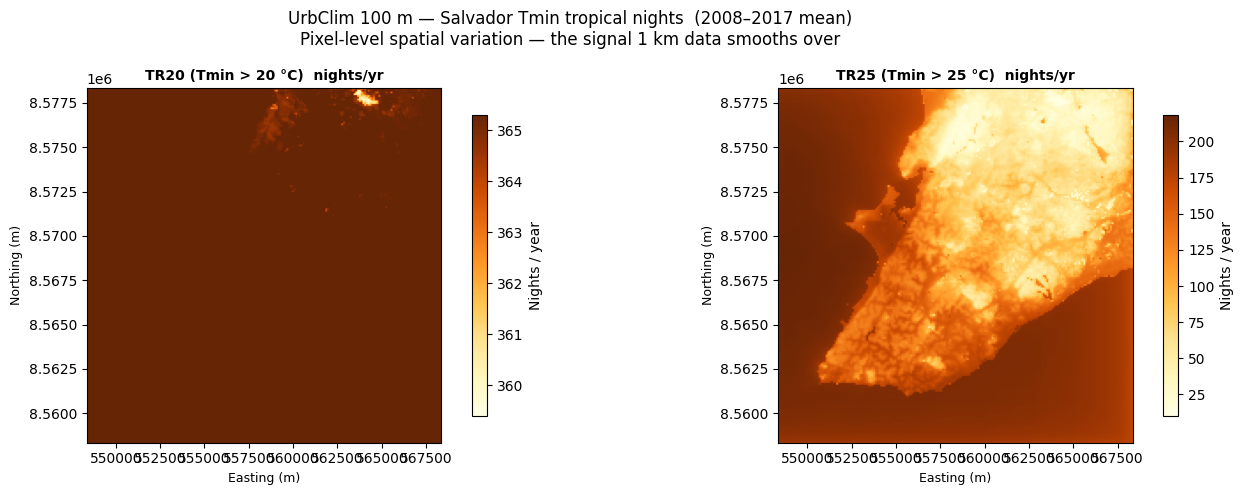

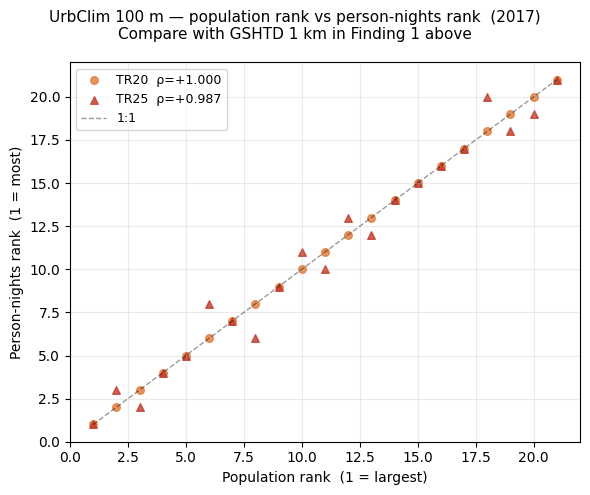


Key takeaway:
  TR20 CV:  1 km = 0.433  →  100 m = 0.000  (×0.0)
  TR25 CV:  1 km = 0.473  →  100 m = 0.295  (×0.6)
  ρ(pop, TR20 person-nights):  1 km = +0.991  →  100 m = +1.000


In [11]:
import glob
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rioxarray          # noqa: F401
from rasterio.transform import Affine
from rasterstats import zonal_stats
from scipy.stats import spearmanr
from pathlib import Path

URBCLIM_DIR = '../data/urbClim_salvador'
URBCLIM_CRS = 'EPSG:32724'
UC_YEARS    = list(range(2008, 2018))

# ---- Load UrbClim daily Tmin (K → °C) --------------------------------------
tmin_files = sorted(glob.glob(f'{URBCLIM_DIR}/T2M_year_daily_min_*.nc'))
print(f'Found {len(tmin_files)} UrbClim Tmin files')

ds_uc  = xr.open_mfdataset(tmin_files, combine='by_coords')
da_tmin_uc = (ds_uc['T2M'] - 273.15).rename('tmin')
da_tmin_uc.attrs['units'] = 'degC'

print(f'Shape : {dict(zip(da_tmin_uc.dims, da_tmin_uc.shape))}')
print(f'Period: {str(da_tmin_uc.time.values[0])[:10]} to {str(da_tmin_uc.time.values[-1])[:10]}')
print(f'Tmin range: {float(da_tmin_uc.min()):.1f} – {float(da_tmin_uc.max()):.1f} °C')

# ---- Annual tropical-night maps (100 m) ------------------------------------
tr20_uc = {}; tr25_uc = {}
for yr in UC_YEARS:
    da_yr = da_tmin_uc.sel(time=da_tmin_uc.time.dt.year == yr)
    tr20_uc[yr] = (da_yr > 20.0).sum(dim='time').rename('tr20')
    tr25_uc[yr] = (da_yr > 25.0).sum(dim='time').rename('tr25')

tr20_mean_uc = xr.concat(list(tr20_uc.values()), dim='year').mean('year')
tr25_mean_uc = xr.concat(list(tr25_uc.values()), dim='year').mean('year')

print(f'\nUrbClim 100 m  (2008–2017 mean):')
print(f'  TR20: min={float(tr20_mean_uc.min()):.1f}  max={float(tr20_mean_uc.max()):.1f}  CV={float(tr20_mean_uc.std()/tr20_mean_uc.mean()):.3f}')
print(f'  TR25: min={float(tr25_mean_uc.min()):.1f}  max={float(tr25_mean_uc.max()):.1f}  CV={float(tr25_mean_uc.std()/tr25_mean_uc.mean()):.3f}')

# ---- Build affine transform (matches notebook 08) --------------------------
xs = da_tmin_uc.x.values
ys = da_tmin_uc.y.values
dx = float(xs[1] - xs[0])
dy = float(ys[1] - ys[0])
affine_transform = Affine(dx, 0.0, xs[0] - dx/2, 0.0, -dy, ys[-1] + dy/2)

# ---- Load cached UTM population grids (written by notebook 08) --------------
pop_utm = {}
for yr in UC_YEARS:
    cache = Path(DATA_DIR) / f'salvador_pop_100m_utm_{yr}.nc'
    if cache.exists():
        pop_utm[yr] = xr.open_dataset(cache)['population']
    else:
        print(f'  WARNING: {cache} not found — run notebook 08 first to build UTM pop cache')

# ---- Neighbourhood boundaries in UTM CRS -----------------------------------
gdf_wgs  = load_neighbourhood_boundaries('salvador', DATA_DIR)
gdf_utm  = gdf_wgs.to_crs(URBCLIM_CRS)

def zonal(array_2d, stat):
    return zonal_stats(
        gdf_utm,
        np.flipud(array_2d.astype(float)),
        affine=affine_transform,
        stats=[stat],
        nodata=np.nan,
    )

# ---- Aggregate to neighbourhoods (2017 — last full UrbClim year) ------------
DIAG_UC = 2017
pop_arr   = pop_utm[DIAG_UC].values
tr20_arr  = tr20_uc[DIAG_UC].values.astype(float)
tr25_arr  = tr25_uc[DIAG_UC].values.astype(float)
tr20_pd_arr = (tr20_uc[DIAG_UC] * pop_utm[DIAG_UC]).values.astype(float)
tr25_pd_arr = (tr25_uc[DIAG_UC] * pop_utm[DIAG_UC]).values.astype(float)

df_uc = gdf_utm[['name']].copy().reset_index(drop=True)
df_uc['population'] = [r['sum']  for r in zonal(pop_arr,    'sum')]
df_uc['tr20_hd']    = [r['mean'] for r in zonal(tr20_arr,   'mean')]
df_uc['tr25_hd']    = [r['mean'] for r in zonal(tr25_arr,   'mean')]
df_uc['tr20_pd']    = [r['sum']  for r in zonal(tr20_pd_arr,'sum')]
df_uc['tr25_pd']    = [r['sum']  for r in zonal(tr25_pd_arr,'sum')]
df_uc = df_uc.dropna().reset_index(drop=True)

def safe_cv(s):
    m = s.mean(); return s.std()/m if m > 0 else 0.0

cv_pop_uc  = safe_cv(df_uc['population'])
cv_tr20_uc = safe_cv(df_uc['tr20_hd'])
cv_tr25_uc = safe_cv(df_uc['tr25_hd'])
rho_pop_tr20_uc, _ = spearmanr(df_uc['population'], df_uc['tr20_pd'])
rho_pop_tr25_uc, _ = spearmanr(df_uc['population'], df_uc['tr25_pd'])

print(f'\nUrbClim 100 m neighbourhood stats  ({DIAG_UC}):')
print(f'  TR20 neighbourhood: mean={df_uc["tr20_hd"].mean():.1f}  range={df_uc["tr20_hd"].min():.0f}–{df_uc["tr20_hd"].max():.0f}  CV={cv_tr20_uc:.3f}')
print(f'  TR25 neighbourhood: mean={df_uc["tr25_hd"].mean():.1f}  range={df_uc["tr25_hd"].min():.0f}–{df_uc["tr25_hd"].max():.0f}  CV={cv_tr25_uc:.3f}')

# ---- Comparison table: 1 km vs 100 m ---------------------------------------
# Retrieve 1km values already computed earlier in this notebook
df_1km = tables['salvador']
cv_pop_1km  = safe_cv(df_1km['population'])
cv_tr20_1km = safe_cv(df_1km['tr20_hd'])
cv_tr25_1km = safe_cv(df_1km['tr25_hd'])
rho_pop_tr20_1km, _ = spearmanr(df_1km['population'], df_1km['tr20_pd'])
rho_pop_tr25_1km, _ = spearmanr(df_1km['population'], df_1km['tr25_pd'])

comp_rows = [
    {
        'Dataset':              'GSHTD  1 km',
        'CV: population':       cv_pop_1km,
        'CV: TR20 nights':      cv_tr20_1km,
        'CV: TR25 nights':      cv_tr25_1km,
        'Ratio CV(TR20)/CV(pop)': cv_tr20_1km / cv_pop_1km if cv_pop_1km > 0 else np.nan,
        'ρ pop vs TR20 pd':     rho_pop_tr20_1km,
        'ρ pop vs TR25 pd':     rho_pop_tr25_1km,
    },
    {
        'Dataset':              'UrbClim  100 m',
        'CV: population':       cv_pop_uc,
        'CV: TR20 nights':      cv_tr20_uc,
        'CV: TR25 nights':      cv_tr25_uc,
        'Ratio CV(TR20)/CV(pop)': cv_tr20_uc / cv_pop_uc if cv_pop_uc > 0 else np.nan,
        'ρ pop vs TR20 pd':     rho_pop_tr20_uc,
        'ρ pop vs TR25 pd':     rho_pop_tr25_uc,
    },
]

comp_df = pd.DataFrame(comp_rows).set_index('Dataset')
cv_cols  = ['CV: population', 'CV: TR20 nights', 'CV: TR25 nights', 'Ratio CV(TR20)/CV(pop)']
rho_cols = ['ρ pop vs TR20 pd', 'ρ pop vs TR25 pd']

display(
    comp_df.style
    .format({c: '{:.3f}' for c in cv_cols + rho_cols})
    .background_gradient(subset=['CV: TR20 nights', 'CV: TR25 nights'], cmap='YlOrRd', axis=None)
    .background_gradient(subset=rho_cols, cmap='RdYlGn', axis=None, vmin=-1, vmax=1)
    .set_caption(
        f'Resolution comparison — Salvador  |  '
        f'1 km diagnostic year: {DIAG_YEAR}  |  100 m diagnostic year: {DIAG_UC}  |  '
        'Higher CV = more spatial discrimination'
    )
    .set_table_styles(table_styles)
)

# ---- Side-by-side pixel maps: 100 m thermal landscape ----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'UrbClim 100 m — Salvador Tmin tropical nights  (2008–2017 mean)\n'
    'Pixel-level spatial variation — the signal 1 km data smooths over',
    fontsize=12,
)
for ax, arr, title in [
    (axes[0], tr20_mean_uc.values, 'TR20 (Tmin > 20 °C)  nights/yr'),
    (axes[1], tr25_mean_uc.values, 'TR25 (Tmin > 25 °C)  nights/yr'),
]:
    im = ax.imshow(
        arr, origin='lower', cmap='YlOrBr',
        extent=[float(da_tmin_uc.x.min()), float(da_tmin_uc.x.max()),
                float(da_tmin_uc.y.min()), float(da_tmin_uc.y.max())],
    )
    plt.colorbar(im, ax=ax, label='Nights / year', shrink=0.85)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Easting (m)', fontsize=9); ax.set_ylabel('Northing (m)', fontsize=9)

plt.tight_layout()
plt.show()

# ---- Population rank vs person-nights rank at 100 m (mirrors Fig 1) --------
n = len(df_uc)
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle(
    f'UrbClim 100 m — population rank vs person-nights rank  ({DIAG_UC})\n'
    'Compare with GSHTD 1 km in Finding 1 above',
    fontsize=11,
)
rho20, _ = spearmanr(df_uc['population'], df_uc['tr20_pd'])
rho25, _ = spearmanr(df_uc['population'], df_uc['tr25_pd'])
ax.scatter(
    df_uc['population'].rank(ascending=False),
    df_uc['tr20_pd'].rank(ascending=False),
    s=30, alpha=0.8, color='#e07b39', label=f'TR20  ρ={rho20:+.3f}',
)
ax.scatter(
    df_uc['population'].rank(ascending=False),
    df_uc['tr25_pd'].rank(ascending=False),
    s=30, alpha=0.8, color='#c0392b', marker='^', label=f'TR25  ρ={rho25:+.3f}',
)
ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.4, label='1:1')
ax.set_xlabel('Population rank  (1 = largest)', fontsize=10)
ax.set_ylabel('Person-nights rank  (1 = most)', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f'\nKey takeaway:')
print(f'  TR20 CV:  1 km = {cv_tr20_1km:.3f}  →  100 m = {cv_tr20_uc:.3f}  (×{cv_tr20_uc/cv_tr20_1km:.1f})')
print(f'  TR25 CV:  1 km = {cv_tr25_1km:.3f}  →  100 m = {cv_tr25_uc:.3f}  (×{cv_tr25_uc/cv_tr25_1km:.1f})')
print(f'  ρ(pop, TR20 person-nights):  1 km = {rho_pop_tr20_1km:+.3f}  →  100 m = {rho_pop_tr20_uc:+.3f}')

### Why the 100 m results are counter-intuitive — dataset bias, not resolution

The outputs show the opposite of what notebook 08 found for Tmax absolute heat days:

| | 1 km (GSHTD) | 100 m (UrbClim) | Direction |
|---|---|---|---|
| TR20 CV | 0.433 | **0.000** | ↓ worse |
| TR25 CV | 0.473 | **0.295** | ↓ worse |

This is not a resolution effect — it is a **dataset bias effect**.

**The cause:** UrbClim Tmin is systematically ~3 °C *warmer* than GSHTD Tmin.  This was documented when comparing the two datasets for Salvador (notebook 14 / project notes: "ISU GSHTD Tmin ~3 °C cooler than VITO UrbClim").  The UrbClim model is a high-resolution urban climate simulation forced by ERA5; it captures the nocturnal UHI and tends to produce warmer near-surface minimums than the satellite-derived GSHTD.

**The consequence for absolute thresholds:** Applying the same 20 °C and 25 °C thresholds to both datasets is not a like-for-like comparison:

| Dataset | Effective Tmin climatology | TR20 nights/yr | TR20 saturated? |
|---|---|---|---|
| GSHTD 1 km | cooler (~18–24 °C range across pixels) | 102 / yr (28%) | No — useful signal |
| UrbClim 100 m | warmer (~19–28 °C range across pixels) | **362 / yr (99%)** | **Yes — completely** |

At 100 m, UrbClim Tmin barely dips below 20 °C — even the coolest pixel averages 359 tropical nights per year.  The threshold is wrong for this dataset, not the resolution.

**TR25 at 100 m pixel level (CV = 0.41) is actually informative** — the pixel-level map shows genuine spatial structure (range 10–219 nights/yr across the 201×201 grid), consistent with the nocturnal UHI being resolved at 100 m.  The problem is that this variation is mostly *within* neighbourhoods, not *between* them.  When aggregated to 22 neighbourhood polygons, CV drops to 0.295 — below the 1 km value of 0.473 — because the UHI structure is sub-neighbourhood scale.

**What a fair comparison would require:**
1. Apply a *dataset-adjusted* threshold: if UrbClim Tmin is ~3 °C warmer, TR20 on GSHTD ≈ TR23 on UrbClim.  Applying TR23 and TR28 to UrbClim would test the same physiological threshold on both datasets.
2. Alternatively, use a relative threshold (TN90p) which normalises out the bias — but as notebook 08 showed, relative thresholds suppress the very UHI signal we want to measure.

**The core finding stands, but the reason is now clearer:** the 1 km resolution is not the binding constraint for tropical nights in Salvador — the GSHTD dataset happens to capture enough of the coastal/inland Tmin gradient at 1 km to produce reasonable neighbourhood CV (0.43).  The resolution hypothesis would need to be tested with a consistent dataset (e.g. downscaling GSHTD to 100 m, or applying a bias-corrected UrbClim threshold) before conclusions can be drawn about whether 100 m would genuinely improve tropical-night discrimination.